In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from scipy.sparse import issparse

import gc

sc.settings.set_figure_params(
    dpi=300,           
    frameon=False,     
    #figsize=(6, 5),    
    fontsize=16,       
    #format='pdf'     
)

In [2]:
# --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_standard_norm_lncRNA.h5ad")
#adata = sc.read_h5ad("../data/data_pearson_norm_lncRNA.h5ad")

## Clustering and global markers

/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_7434/1873234919.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.4, random_state=12)


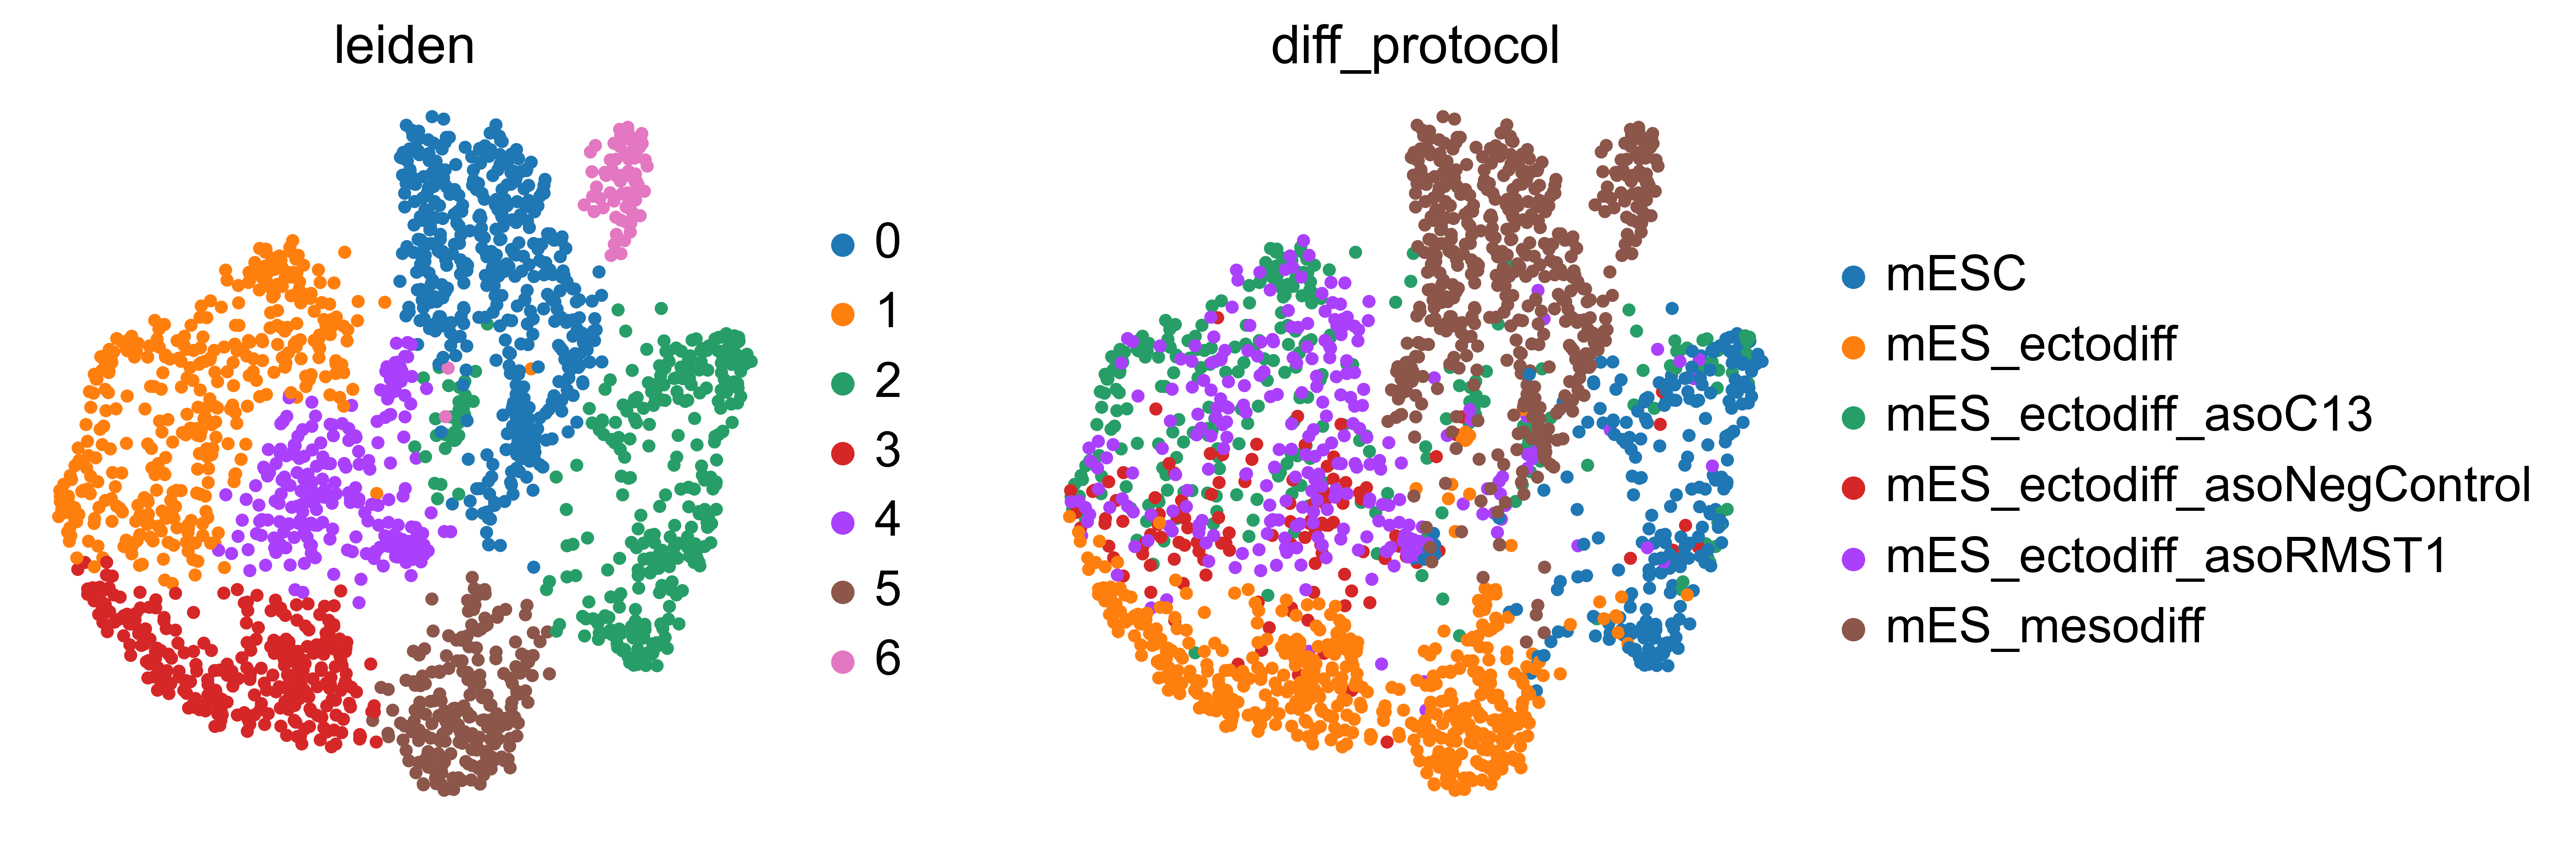

In [3]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=19)
sc.tl.umap(adata, random_state=12) 

# --- CLUSTERING (Leiden method) ---

# Higher resolution = higher number of clusters

sc.tl.leiden(adata, resolution=0.4, random_state=12)
sc.tl.dendrogram(adata, groupby='leiden')

# Visualize clusters alongside the experiments
sc.pl.umap(adata, color=['leiden','diff_protocol'])

Check the cluster consistency with canonical markers:

Generating targeted Dotplot...


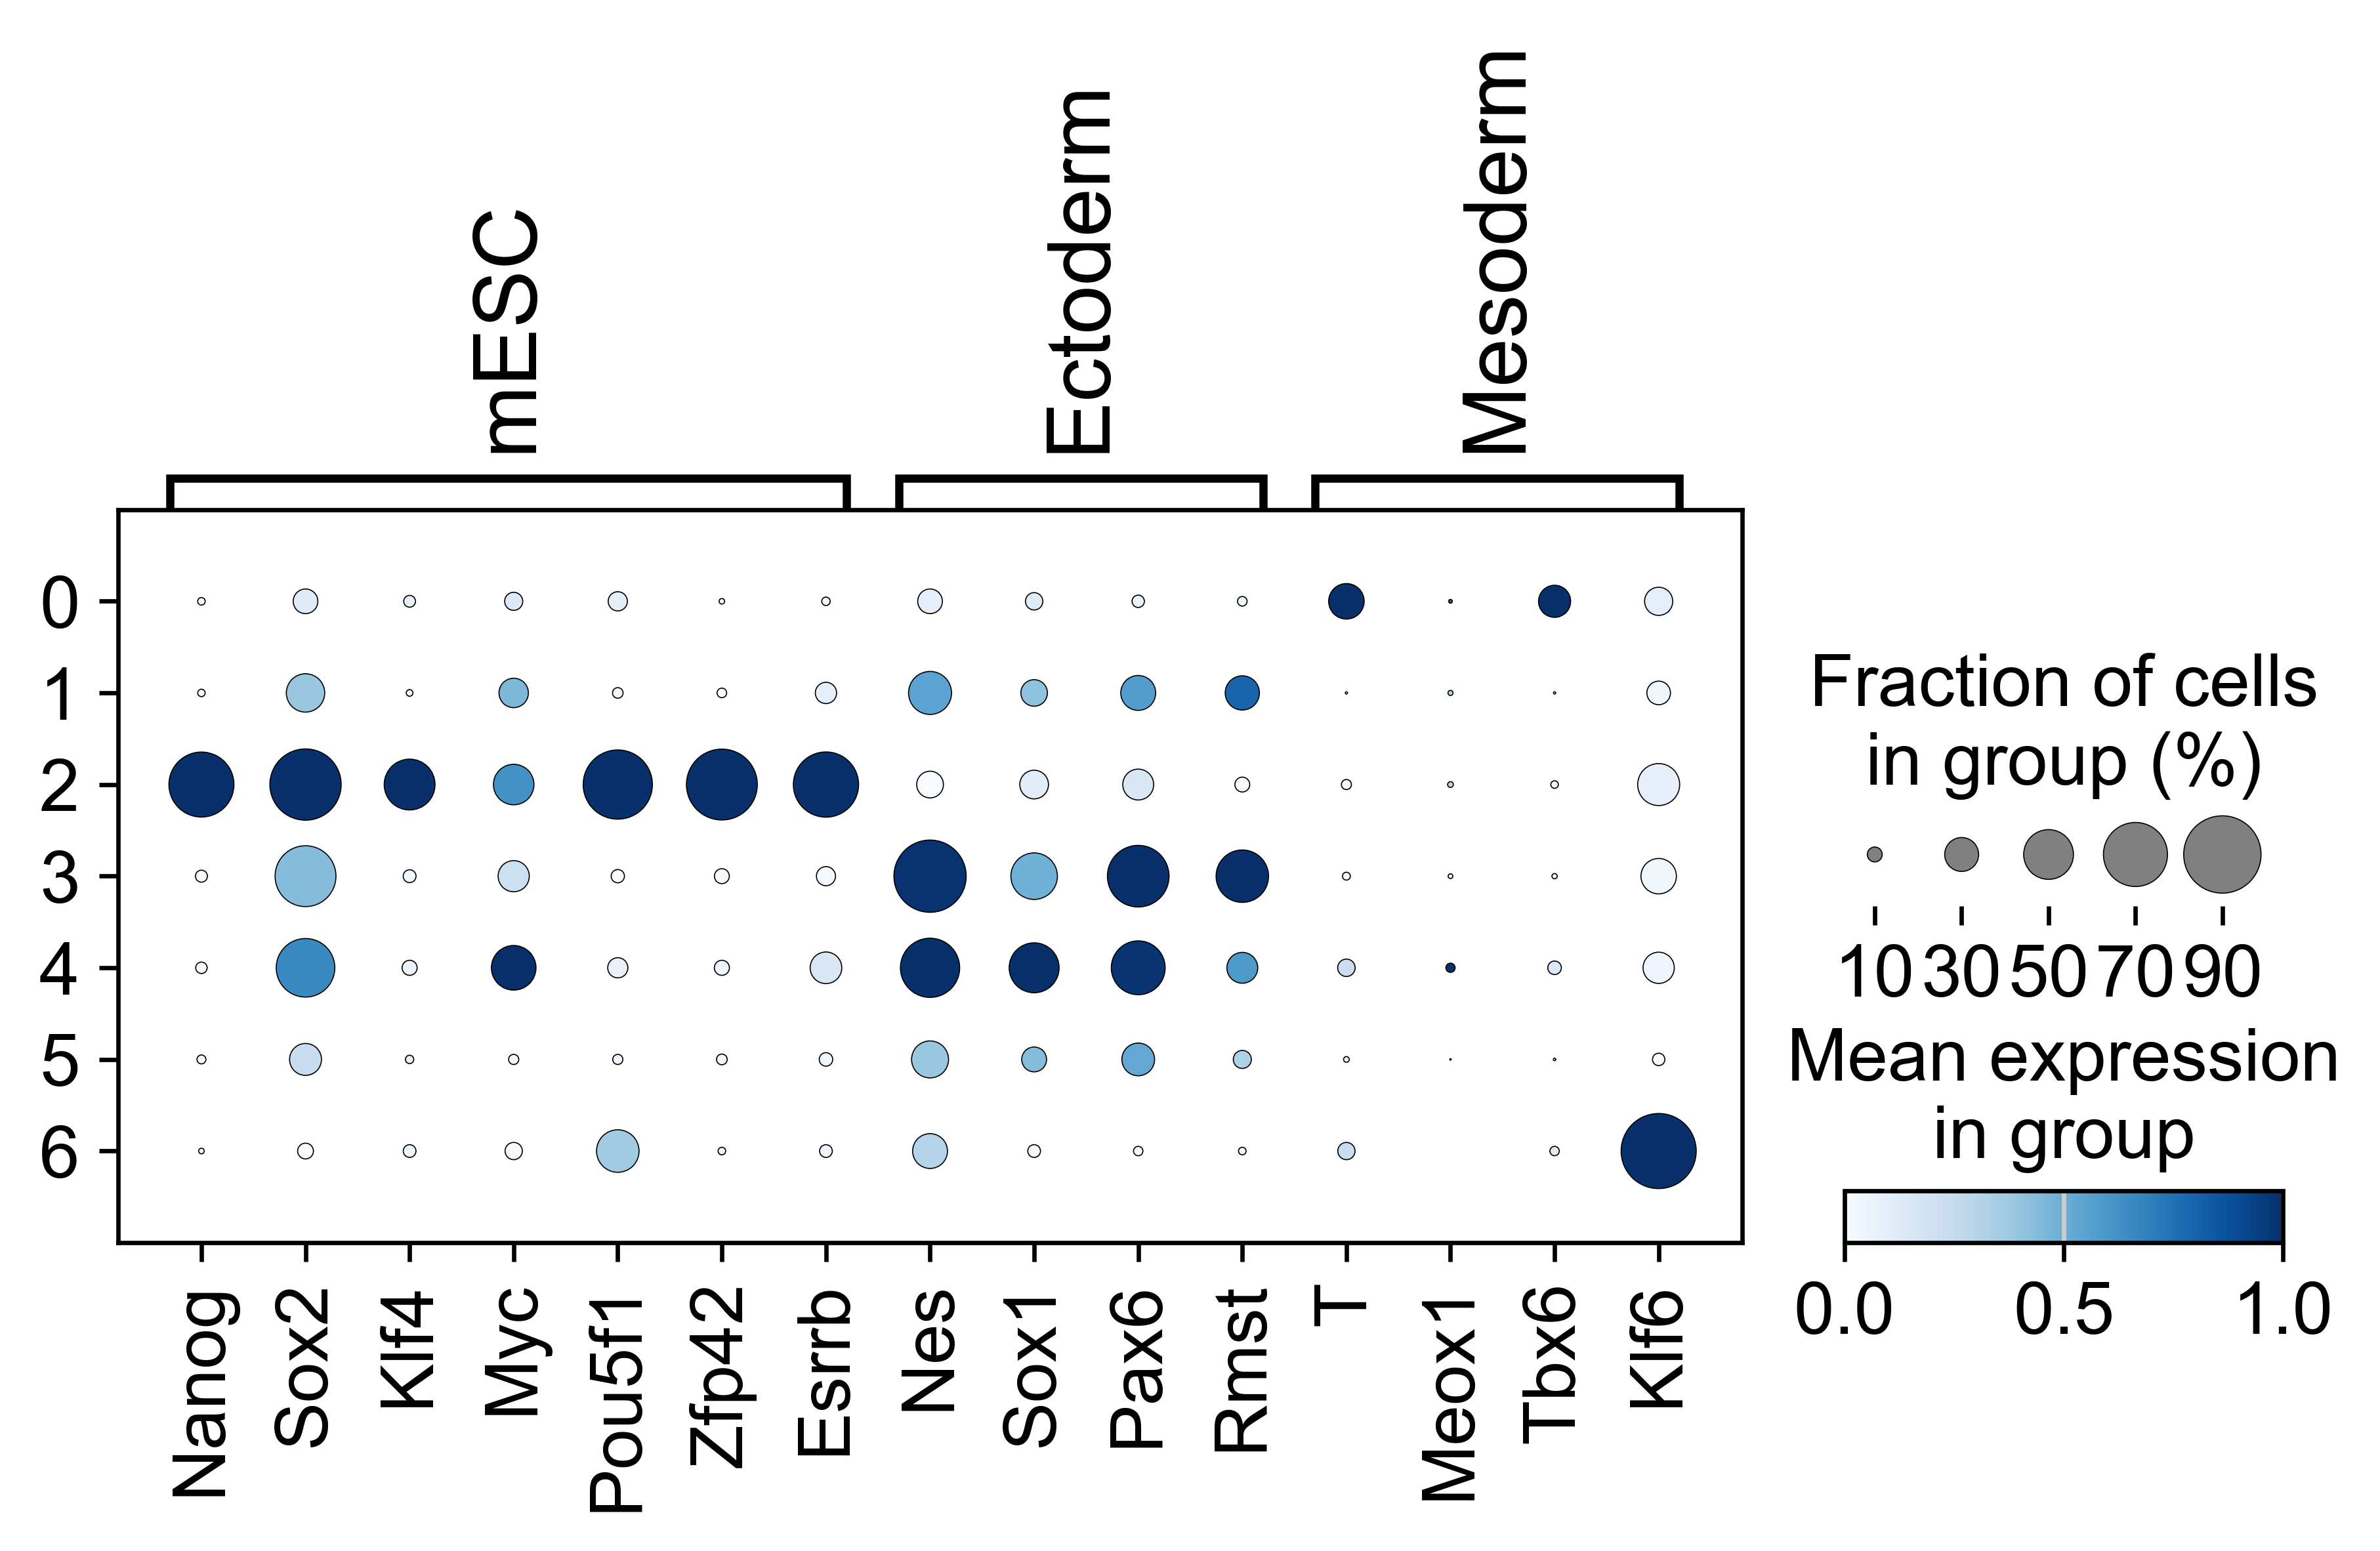

In [4]:
# --- TARGETED MARKER VISUALIZATION ---
# Define your canonical markers of interest
# Add any other literature markers you need
canonical_markers = {
    'mESC':['Nanog','Sox2', 'Klf4','Myc','Pou5f1','Zfp42','Esrrb'],
    'Ectoderm':['Nes','Sox1','Pax6', 'Rmst'],
    'Mesoderm': ['T','Meox1','Tbx6','Klf6']
}

# 1. Dotplot: Standard visualization in scRNA-seq papers.
# Shows both the fraction of cells expressing the gene (dot size) 
# and the mean expression level (color intensity).
print("Generating targeted Dotplot...")
sc.pl.dotplot(
    adata, 
    var_names=canonical_markers, 
    groupby='leiden', 
    standard_scale='var', # Scales data from 0 to 1 per gene for visual comparison
    cmap='Blues'
)

We add some markers to check the anormal clusters: 

1. early ectoderm markers
2. early mesoderm markers
3. endoderm markers

Generating targeted Dotplot...


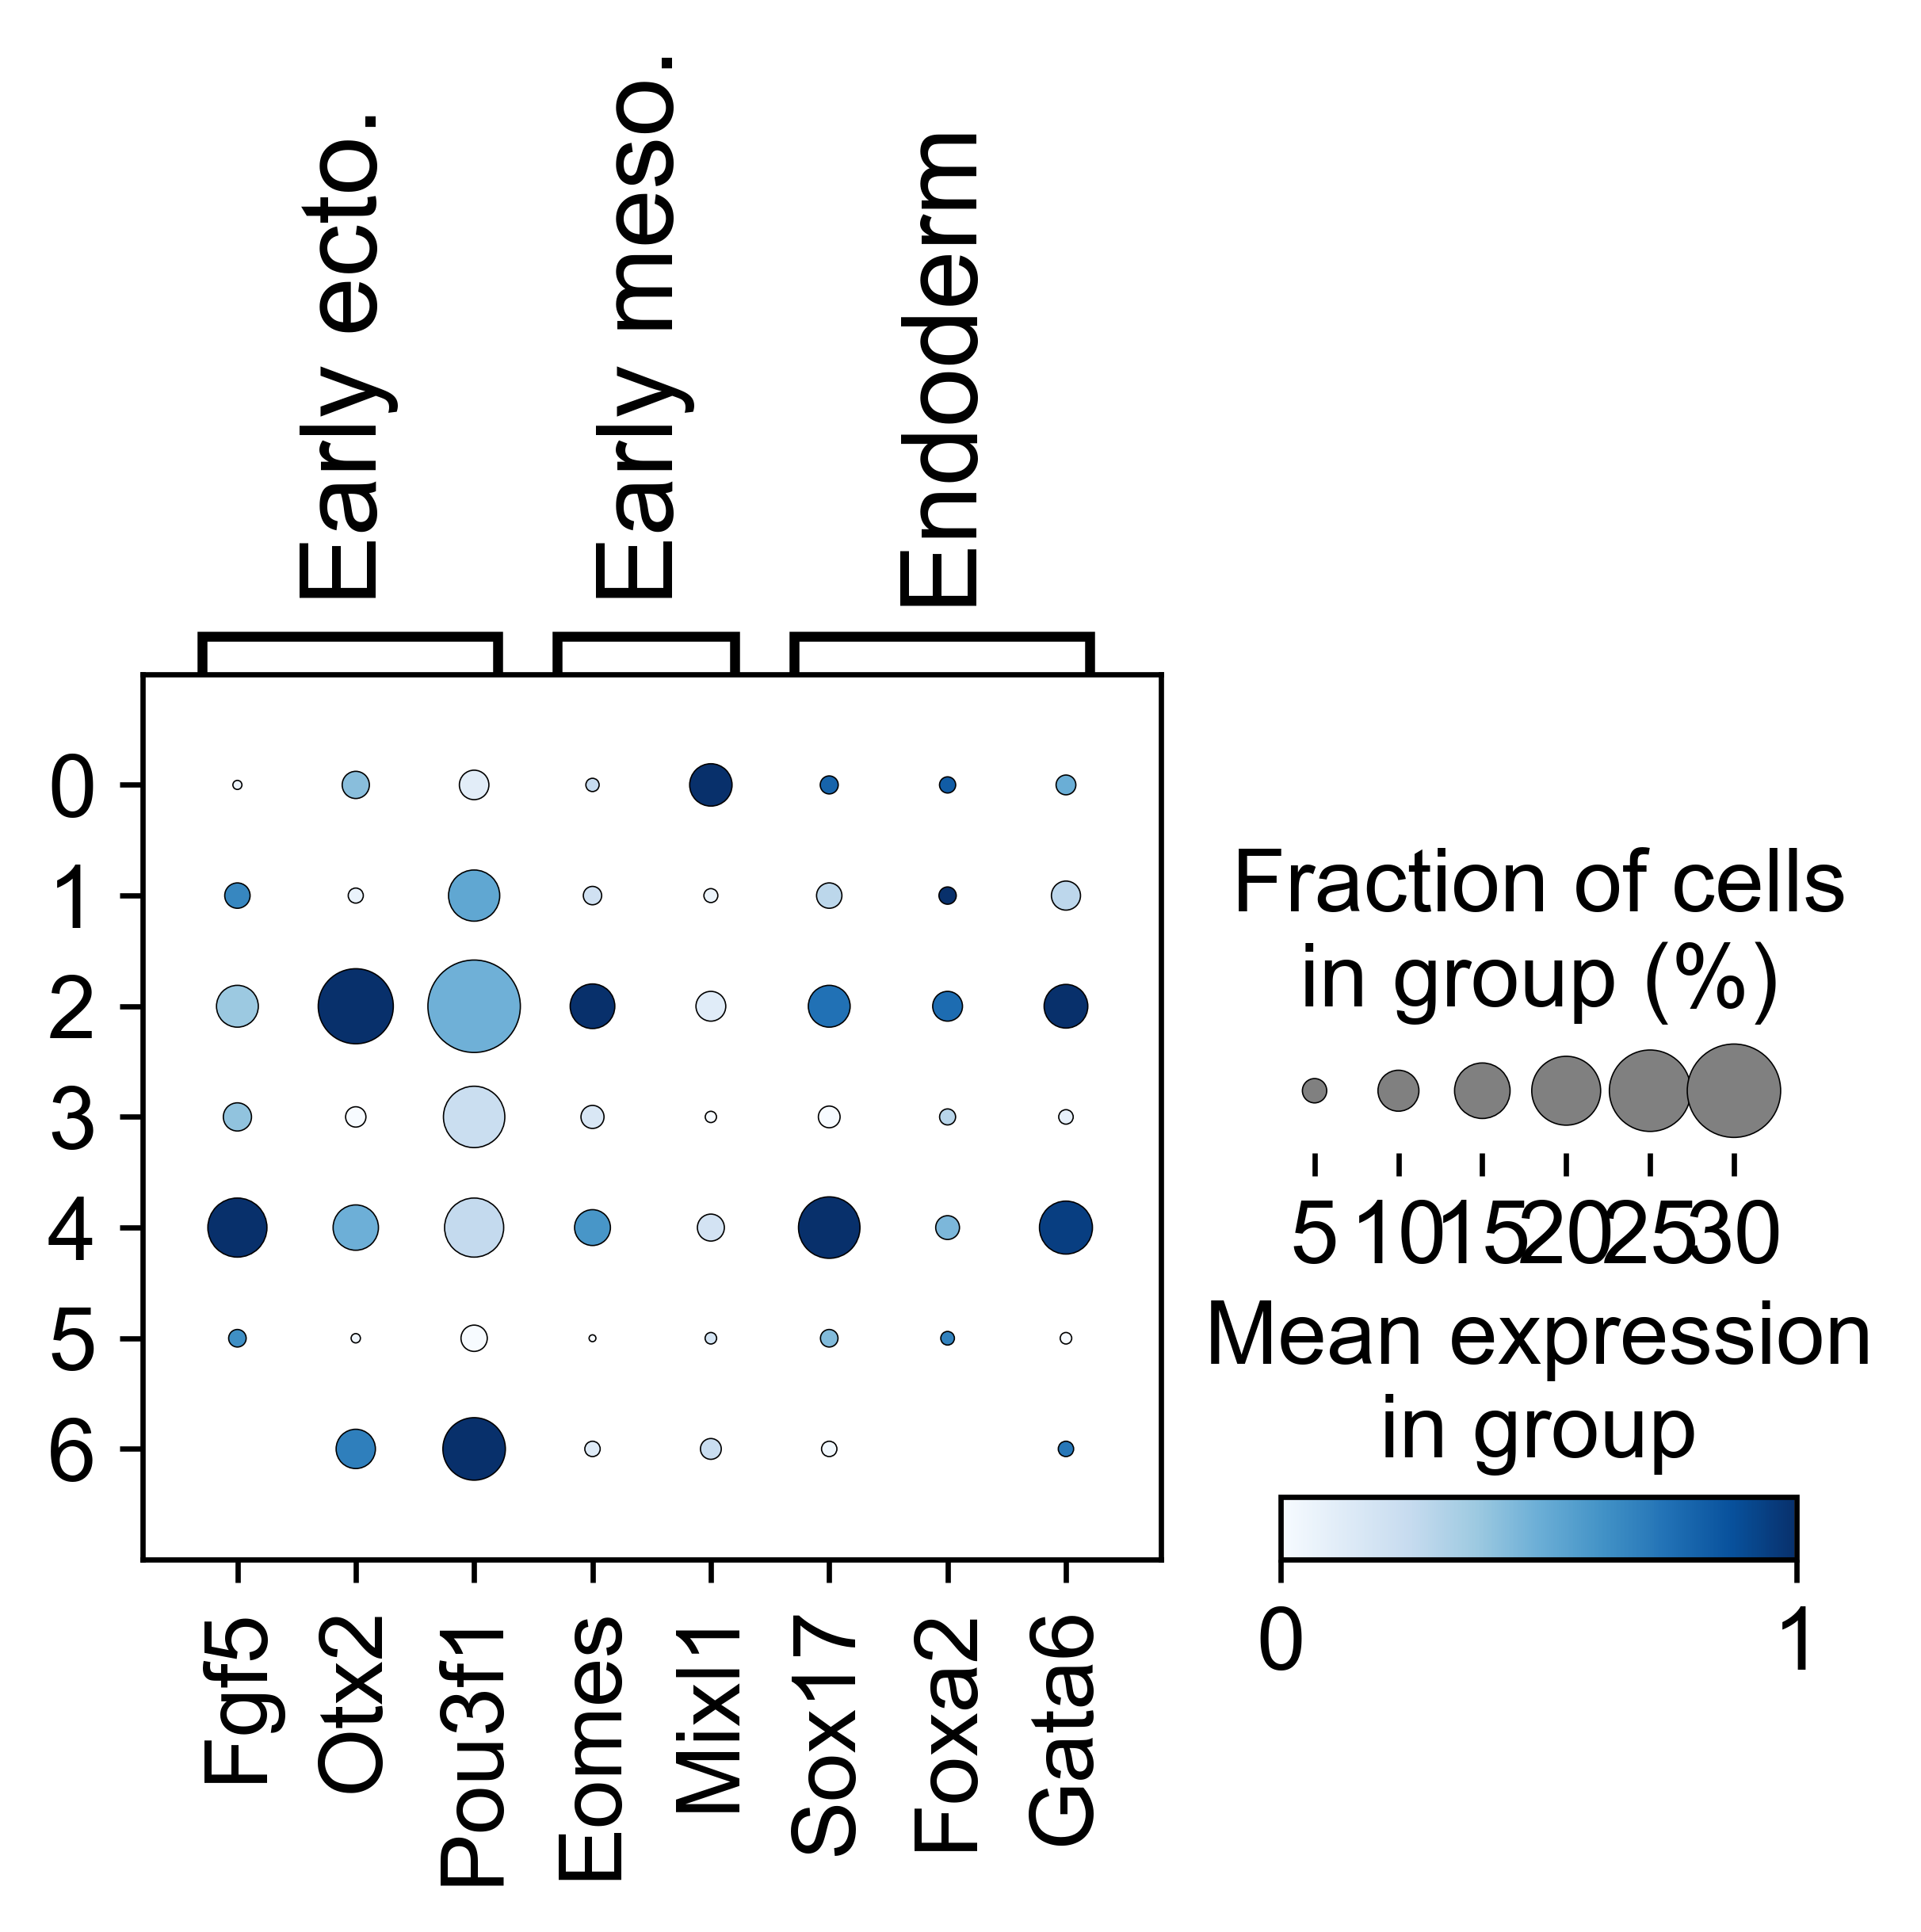

In [5]:
# --- TARGETED MARKER VISUALIZATION ---
# Define your canonical markers of interest
# Add any other literature markers you need
canonical_markers = {
    'Early ecto.':['Fgf5','Otx2','Pou3f1'],
    'Early meso.':['Eomes','Mixl1'],
    'Endoderm': ['Sox17', 'Foxa2','Gata6']
}

# 1. Dotplot: Standard visualization in scRNA-seq papers.
# Shows both the fraction of cells expressing the gene (dot size) 
# and the mean expression level (color intensity).
print("Generating targeted Dotplot...")
sc.pl.dotplot(
    adata, 
    var_names=canonical_markers, 
    groupby='leiden', 
    standard_scale='var', # Scales data from 0 to 1 per gene for visual comparison
    cmap='Blues'
)

Top genes per cluster:

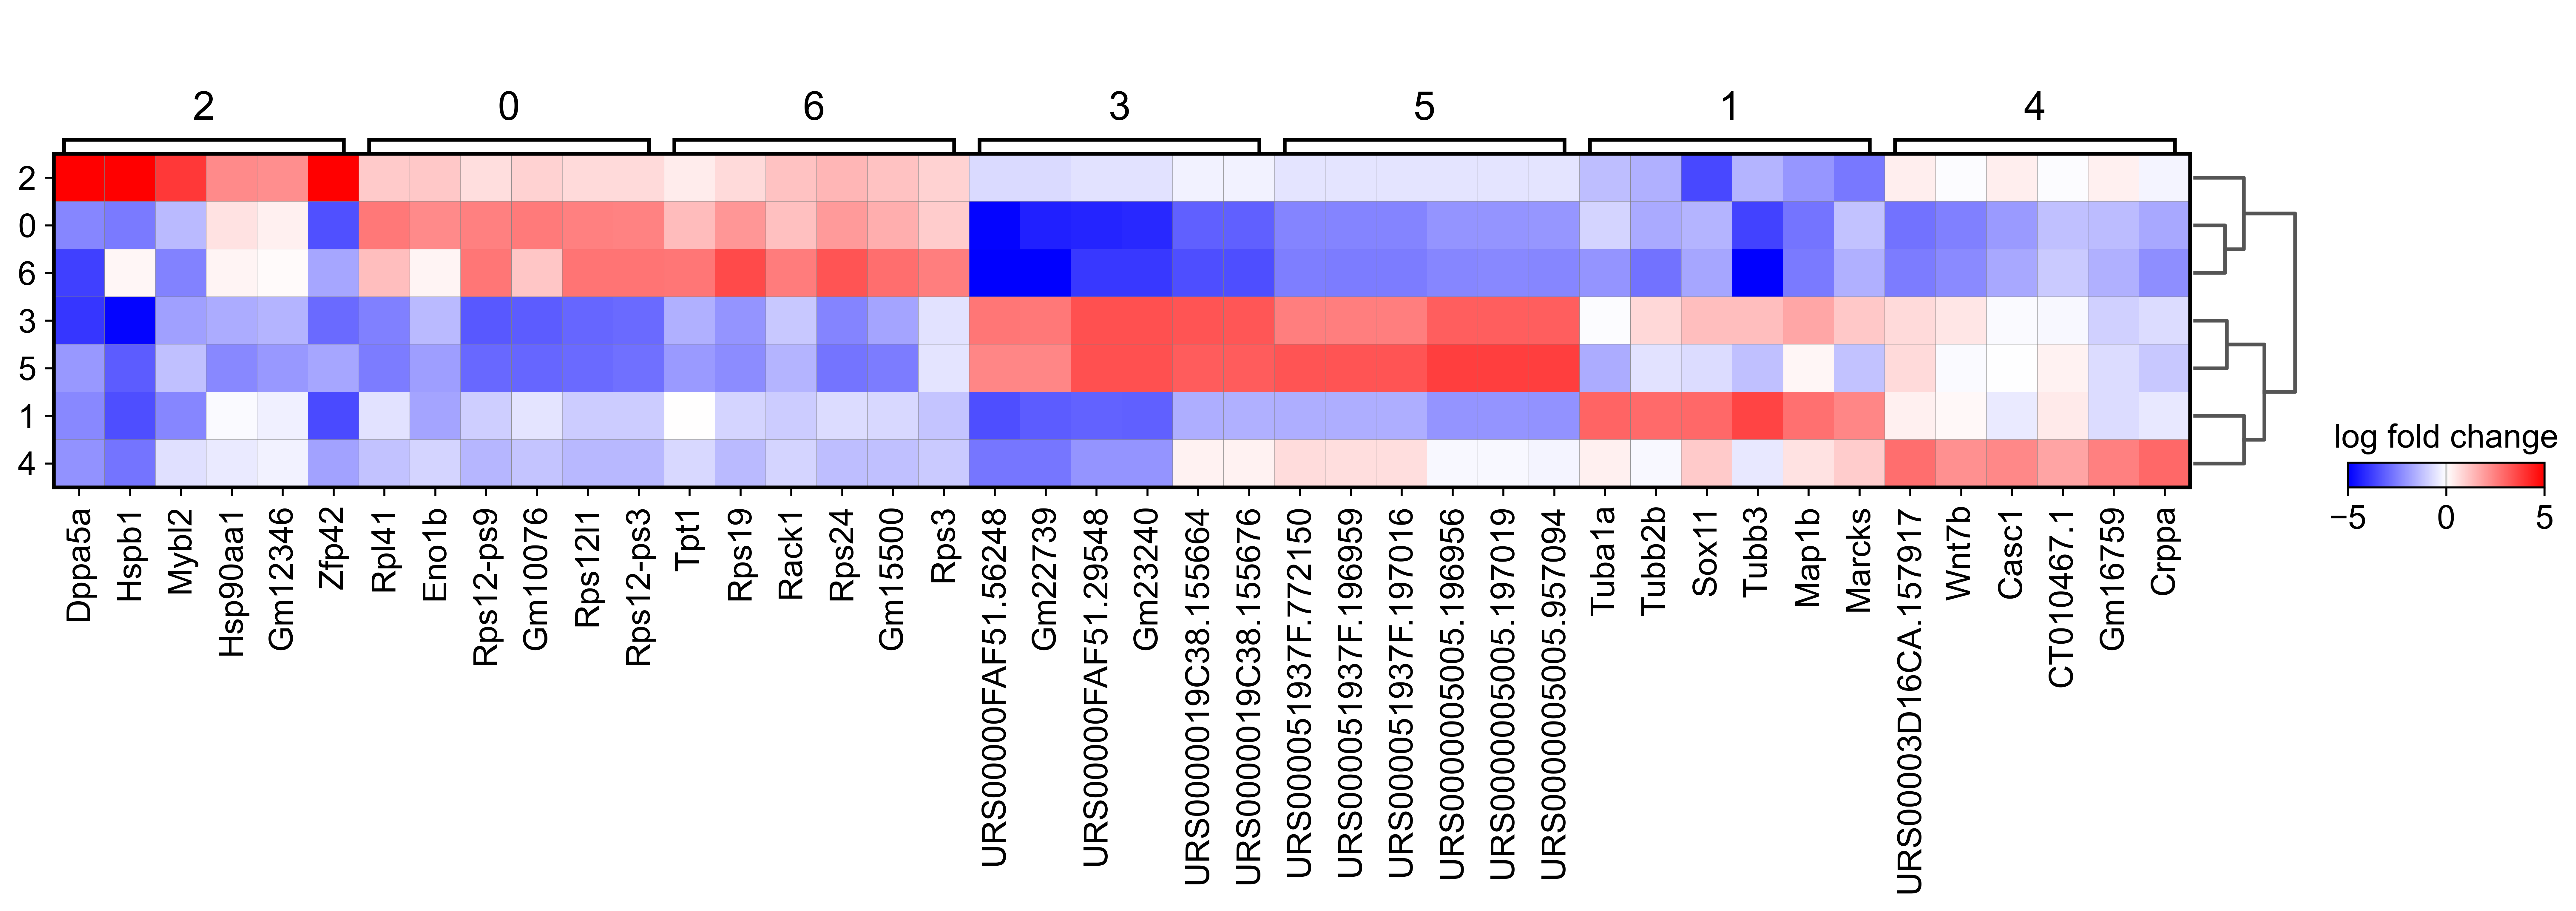

In [41]:
# --- IDENTIFY MARKER GENES PER CLUSTER ---
# We use Wilcoxon rank-sum test. 
# Scanpy automatically uses adata.raw (LogNorm data without z score!!)
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

# Plot top genes per cluster  
sc.pl.rank_genes_groups_matrixplot(
    adata, 
    n_genes=6, 
    values_to_plot='logfoldchanges', 
    cmap='bwr', 
    vmin=-5, vmax=5, 
    min_logfoldchange=1.0 # Only show genes with a strong fold change
)

Composition clusters VS experiments:

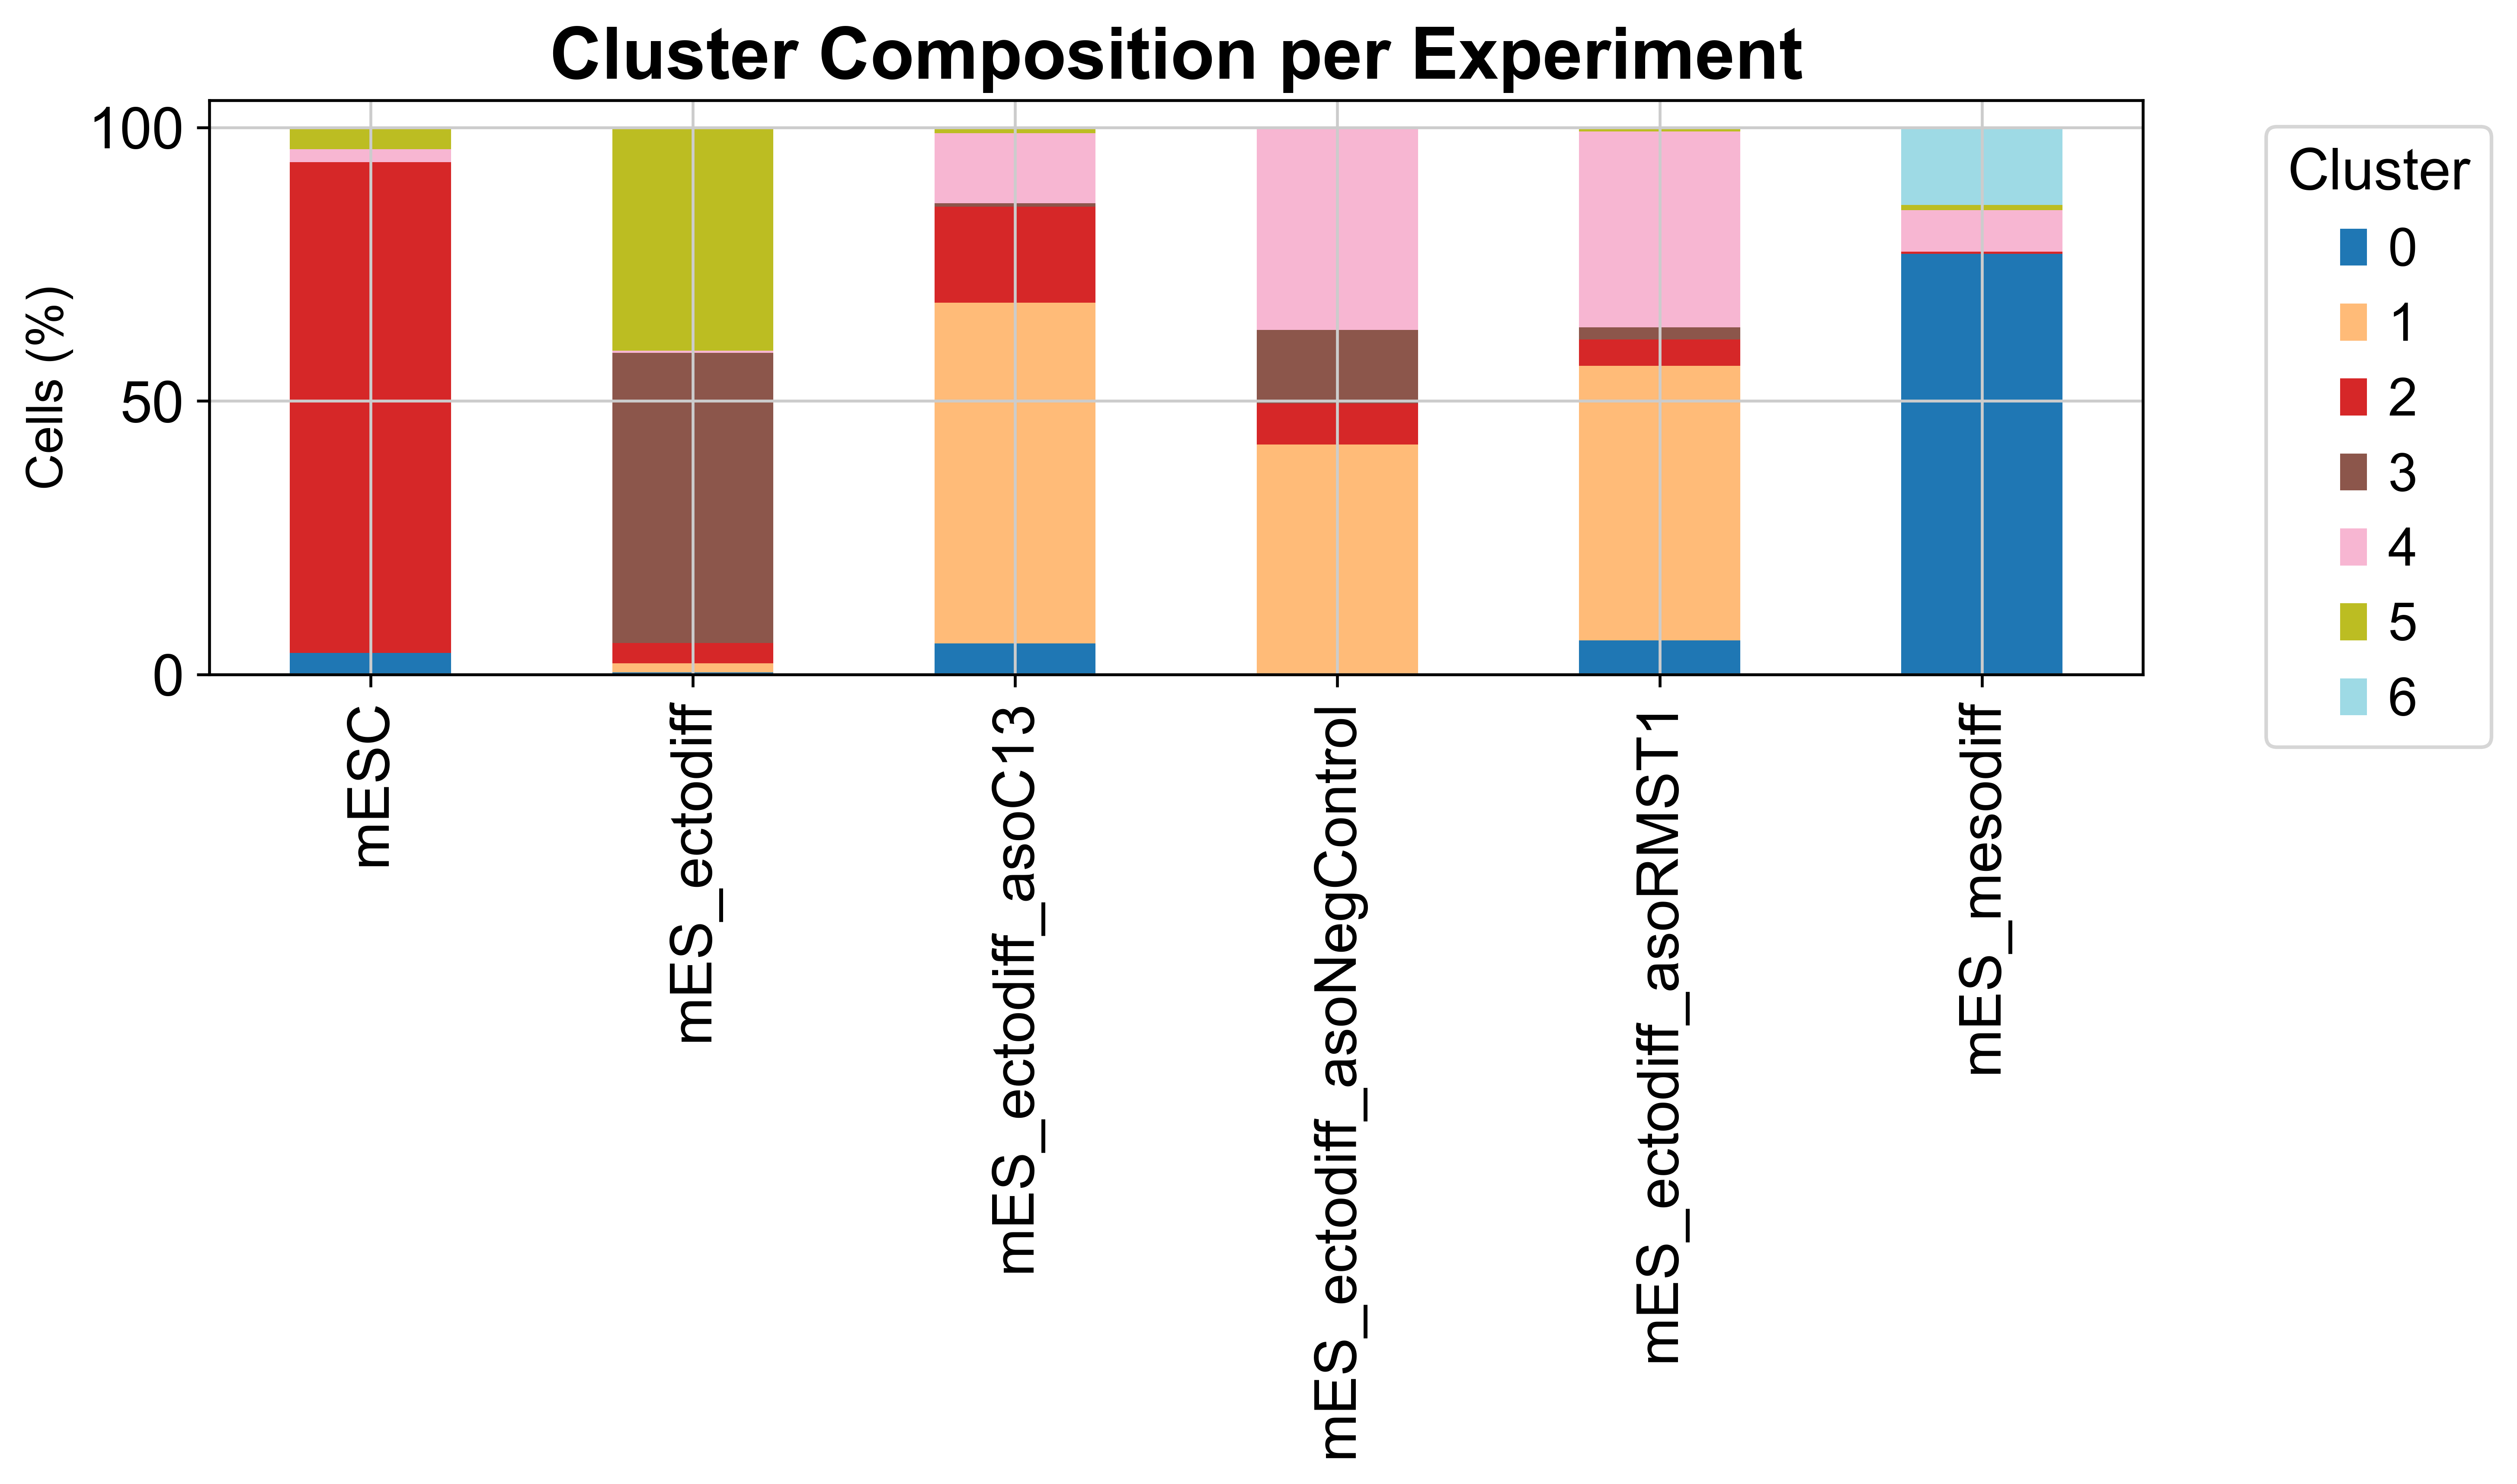

In [35]:
# Create a crosstab counting how many cells from each experiment are in each cluster
composition = pd.crosstab(adata.obs['diff_protocol'], adata.obs['leiden'], normalize='index') * 100

# Plotting as a stacked bar chart
ax = composition.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Cluster Composition per Experiment", fontsize=20, fontweight='bold')
plt.ylabel("Cells (%)", fontsize=14)
plt.xlabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## ASO effect: asoC13 VS negative control

Perturbation impact on fate

Isolating Cluster 5 (Ectoderm) for direct comparison...
Cells in subset: 7


/Users/jaime/miniforge3/envs/lncRNA_ASO/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


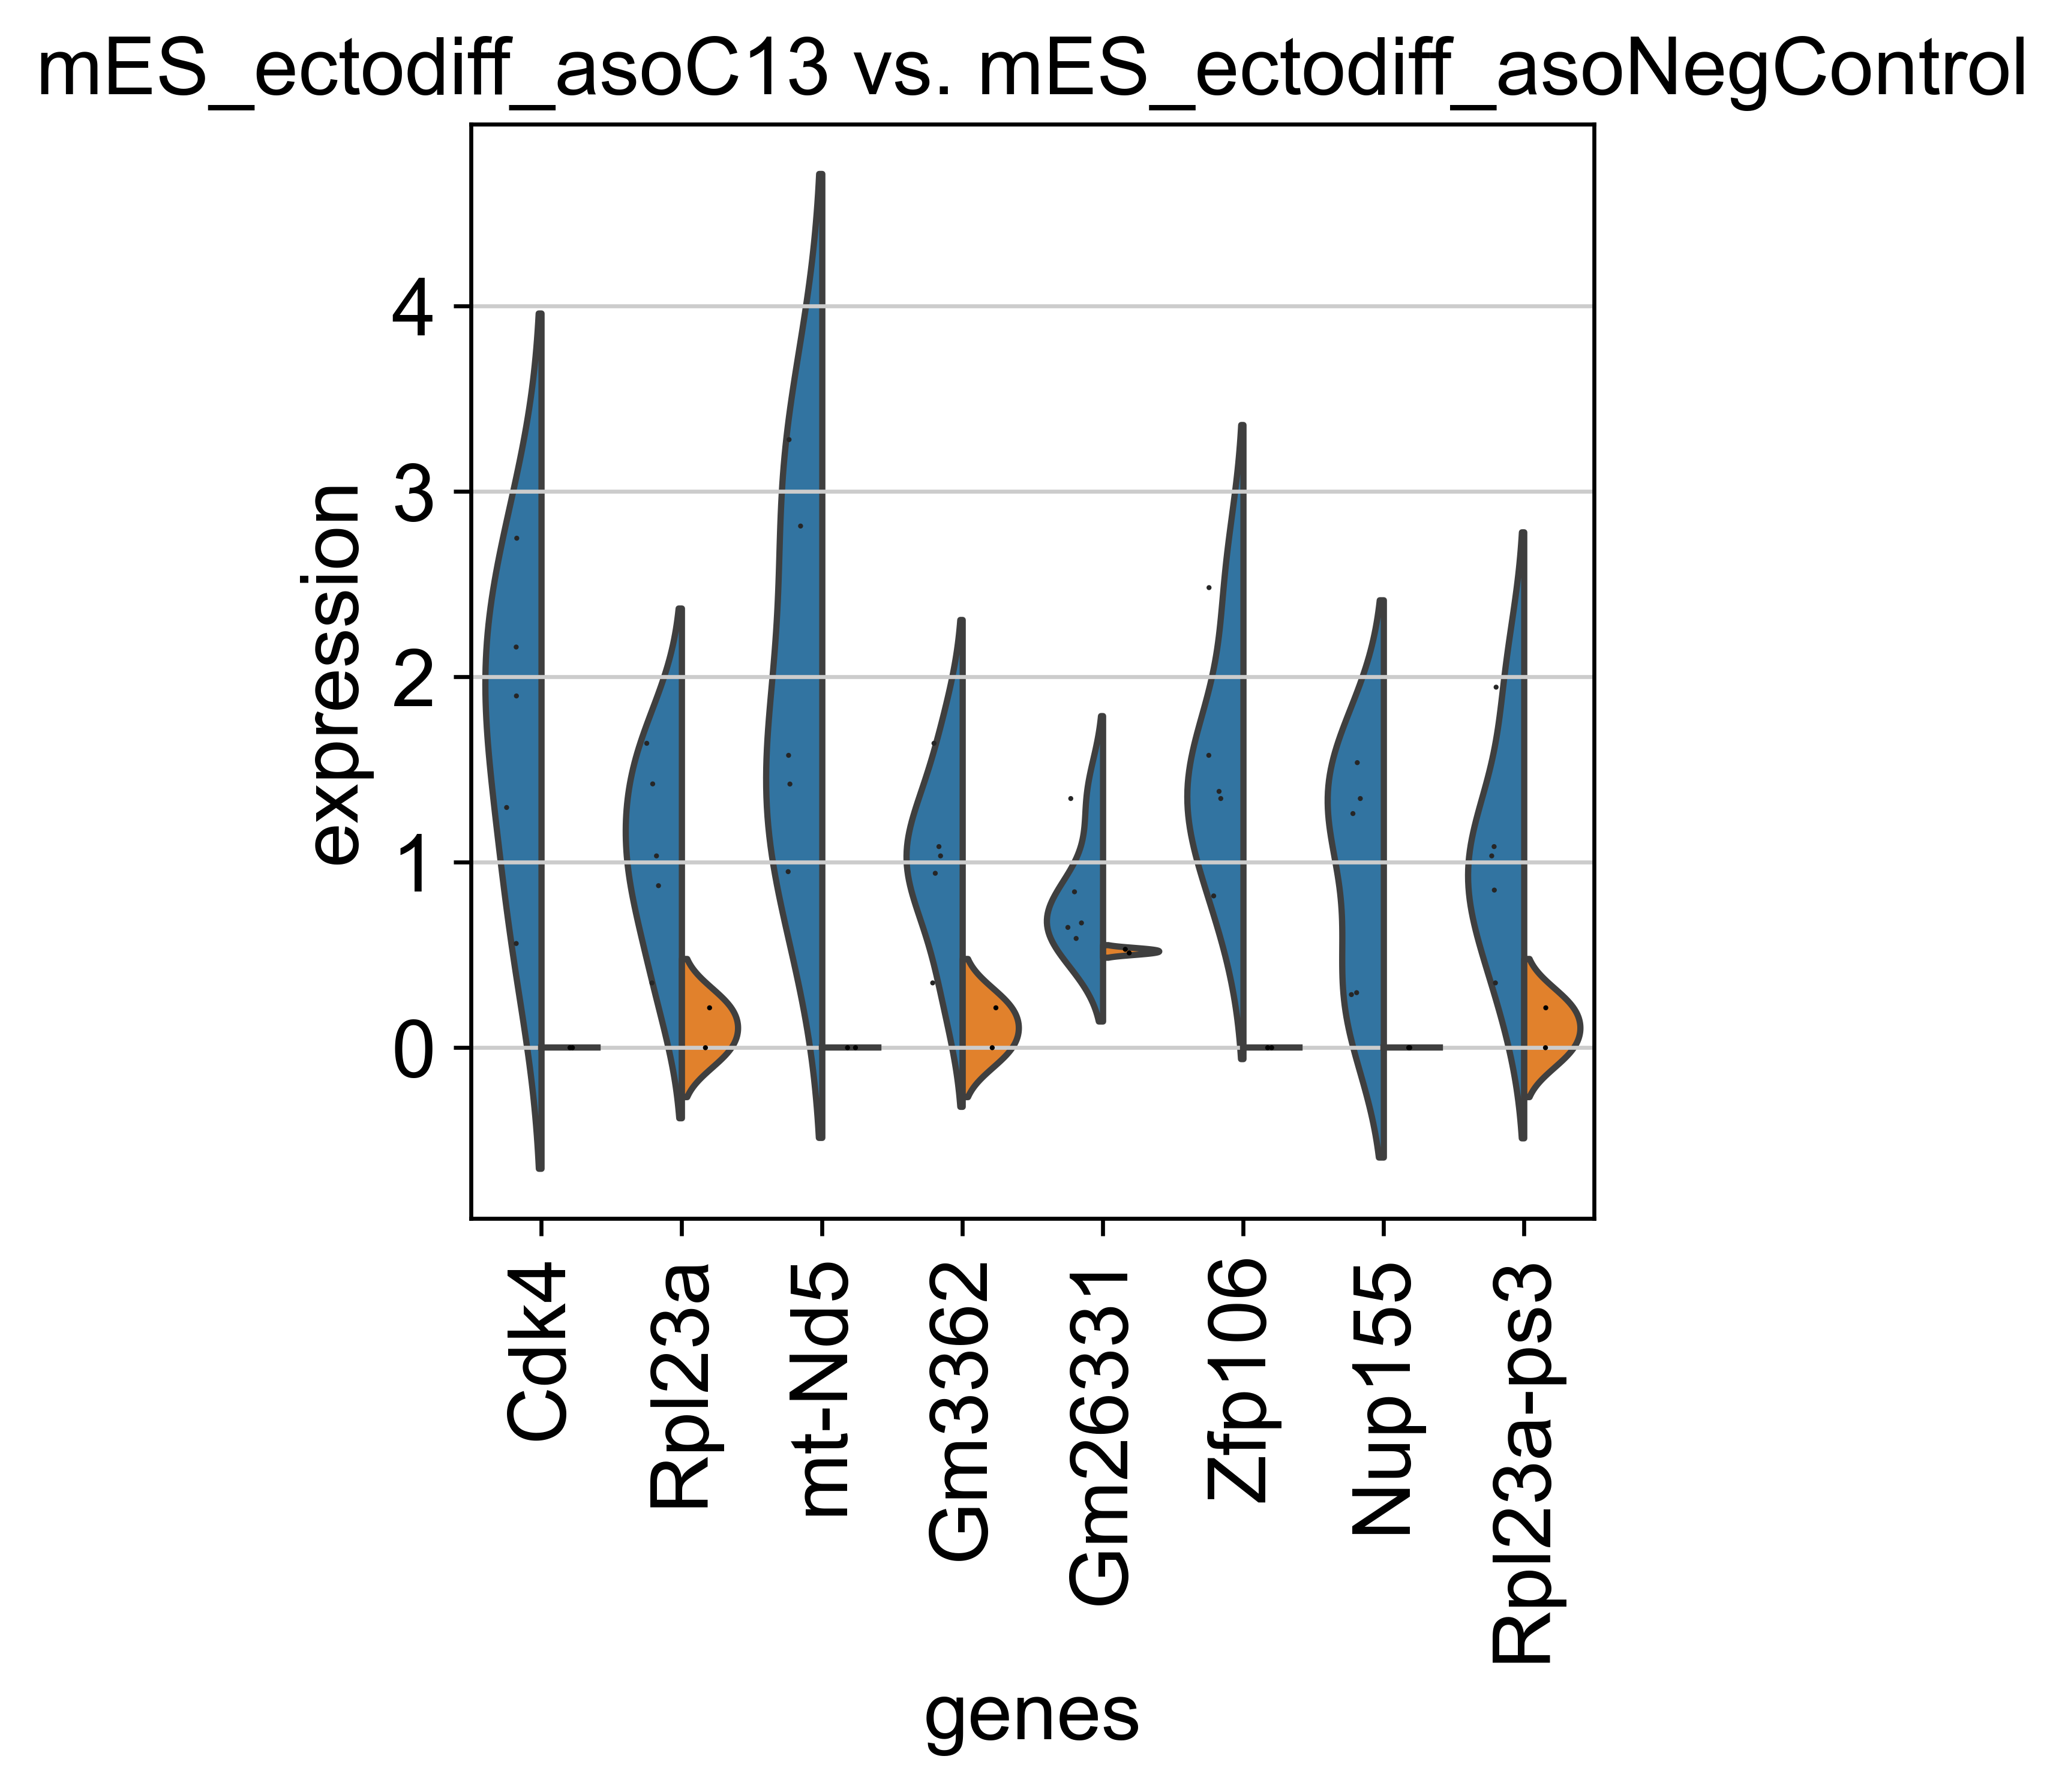

Found 0 significantly dysregulated genes. Saved to CSV.


In [ ]:
# --- DIFFERENTIAL EXPRESSION WITHIN THE TARGET POPULATION ---

ecto_cluster = '3' 

print(f"Isolating Cluster {ecto_cluster} (Ectoderm) for direct comparison...")
# Subset only cells in the target cluster AND from the relevant experiments
mask = (adata.obs['leiden'] == ecto_cluster) & \
       (adata.obs['experiment'].isin(['mES_ectodiff_asoNegControl', 'mES_ectodiff_asoC13']))

adata_subset = adata[mask].copy()

print(f"Cells in subset: {adata_subset.n_obs}")

# Run Differential Expression
# We set reference to the Negative Control to see what changes the C13 ASO caused
sc.tl.rank_genes_groups(
    adata_subset, 
    groupby='experiment', 
    reference='mES_ectodiff_asoNegControl', 
    method='wilcoxon'
)

# Plot the top changed genes
sc.pl.rank_genes_groups_violin(adata_subset, groups=['mES_ectodiff_asoC13'], n_genes=8)

# Save the exact genes that were dysregulated by the ASO
aso_effect_df = sc.get.rank_genes_groups_df(adata_subset, group='mES_ectodiff_asoC13')
# Filter for biological relevance: adjusted p-value < 0.01 and absolute Log2 Fold Change > 0.5
significant_changes = aso_effect_df[(aso_effect_df['pvals_adj'] < 0.01) & (abs(aso_effect_df['logfoldchanges']) > 0.5)]

significant_changes.to_csv("../data/ASO_C13_vs_Control_Ectoderm.csv", index=False)
print(f"Found {len(significant_changes)} significantly dysregulated genes. Saved to CSV.")